In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sheetz06/refined-ecommerce-data-csv/refined_ecommerce_data.csv


In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your cleaned data
df = pd.read_csv('/kaggle/input/datasets/sheetz06/refined-ecommerce-data-csv/refined_ecommerce_data.csv')

# 2. Simulate User IDs (Mapping ~1.2 sessions per user)
np.random.seed(42)
unique_sessions = df['session_id'].unique()
user_ids = np.random.choice(range(1000, 1000 + int(len(unique_sessions)*0.8)), size=len(unique_sessions))
df['user_id'] = user_ids

# 3. Assign Users to Control (A) or Variant (B)
# This ensures a user is ALWAYS in the same group across different sessions
unique_users = df['user_id'].unique()
group_assignment = np.random.choice(['Control', 'Variant'], size=len(unique_users), p=[0.5, 0.5])
user_group_map = dict(zip(unique_users, group_assignment))
df['ab_group'] = df['user_id'].map(user_group_map)

print(f"Total Users: {len(unique_users)}")
print(df['ab_group'].value_counts())

Total Users: 1395
ab_group
Variant    1296
Control    1204
Name: count, dtype: int64


In [3]:
# Create a temporary dataframe of just one row per user to see the true split
user_split = df.drop_duplicates(subset='user_id')['ab_group'].value_counts()

print("True User Split:")
print(user_split)
print(f"\nTotal: {user_split.sum()}")

True User Split:
ab_group
Variant    703
Control    692
Name: count, dtype: int64

Total: 1395


In [10]:
# --- STEP 2: SIMULATE FEATURE IMPACT ---

# 1. Identify the 'Leaky Bucket' users in the Variant group
# (Users who added to cart but didn't buy in the original data)
mask = (df['ab_group'] == 'Variant') & (df['added_to_cart'] == 1) & (df['purchased'] == 0)

# 2. INCREASE THE LIFT: Change frac from 0.12 to 0.15 
# This converts 15% of those 'lost' users into 'purchased'
to_convert = df[mask].sample(frac=0.15, random_state=42).index

# 3. Apply the simulated purchases
df.loc[to_convert, 'purchased'] = 1
df.loc[to_convert, 'order_value_usd'] = df['order_value_usd'].median()

# 4. Fixed Print Statement
print(f"Success! Simulated {len(to_convert)} additional conversions in the Variant group.")

Success! Simulated 44 additional conversions in the Variant group.


In [11]:
# Create a dataframe of ONLY the new conversions in the Variant group
variant_purchases = df[(df['ab_group'] == 'Variant') & (df['purchased'] == 1)]

# See which devices these 'successful' users used
print("New Conversion Breakdown by Device:")
print(variant_purchases['device_type'].value_counts())

# See if their 'time_on_site' changed compared to the Control group
avg_time = df.groupby('ab_group')['time_on_site_minutes'].mean()
print("\nAverage Time on Site per Group:")
print(avg_time)

New Conversion Breakdown by Device:
device_type
0    209
2    175
1    173
Name: count, dtype: int64

Average Time on Site per Group:
ab_group
Control    6.024045
Variant    6.040324
Name: time_on_site_minutes, dtype: float64


In [12]:
# 1. Create a dataframe of ONLY the purchases in the Variant group
variant_purchases = df[(df['ab_group'] == 'Variant') & (df['purchased'] == 1)]

# 2. See which devices these 'successful' users used
print("--- Variant Purchase Breakdown by Device ---")
print(variant_purchases['device_type'].value_counts())

# 3. Efficiency Check: Did users convert faster?
# If your feature (like One-Click Checkout) worked, 
# you might see lower average time on site for buyers in the Variant group.
avg_time = df[df['purchased'] == 1].groupby('ab_group')['time_on_site_minutes'].mean()

print("\n--- Average Time on Site for Buyers (Minutes) ---")
print(avg_time)

time_diff = avg_time['Control'] - avg_time['Variant']
if time_diff > 0:
    print(f"\nInsight: Variant buyers completed their purchase {time_diff:.2f} minutes faster than Control.")

--- Variant Purchase Breakdown by Device ---
device_type
0    209
2    175
1    173
Name: count, dtype: int64

--- Average Time on Site for Buyers (Minutes) ---
ab_group
Control    6.000571
Variant    6.148276
Name: time_on_site_minutes, dtype: float64


In [17]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Standardize naming and group the data
df['ab_group'] = df['ab_group'].str.capitalize()
ab_results = df.groupby('ab_group')['purchased'].agg(['sum', 'count']).reset_index()

# 2. Force explicit extraction by name to avoid order errors
# Extracting Variant first for the Z-test numerator
variant_success = ab_results.loc[ab_results['ab_group'] == 'Variant', 'sum'].values[0]
variant_total = ab_results.loc[ab_results['ab_group'] == 'Variant', 'count'].values[0]

control_success = ab_results.loc[ab_results['ab_group'] == 'Control', 'sum'].values[0]
control_total = ab_results.loc[ab_results['ab_group'] == 'Control', 'count'].values[0]

# 3. Create the lists with [Variant, Control] order
# This ensures the calculation is (Variant Rate - Control Rate)
successes = [variant_success, control_success]
totals = [variant_total, control_total]

# 4. Run the Z-test
z_stat, p_value = proportions_ztest(successes, totals)

# 5. Professional Output
print(f"--- Z-Test Results (95% Confidence) ---")
print(f"Variant Conversion Rate: {variant_success/variant_total:.2%}")
print(f"Control Conversion Rate: {control_success/control_total:.2%}")
print(f"Z-Statistic: {z_stat:.4f}")  # This will now be positive
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ RESULT: STATISTICALLY SIGNIFICANT")
    print(f"The Variant outperformed the Control by {(variant_success/variant_total - control_success/control_total):.2%}")
else:
    print("\n❌ RESULT: NOT STATISTICALLY SIGNIFICANT")

--- Z-Test Results (95% Confidence) ---
Variant Conversion Rate: 42.98%
Control Conversion Rate: 37.79%
Z-Statistic: 2.6404
P-Value: 0.0083

✅ RESULT: STATISTICALLY SIGNIFICANT
The Variant outperformed the Control by 5.19%


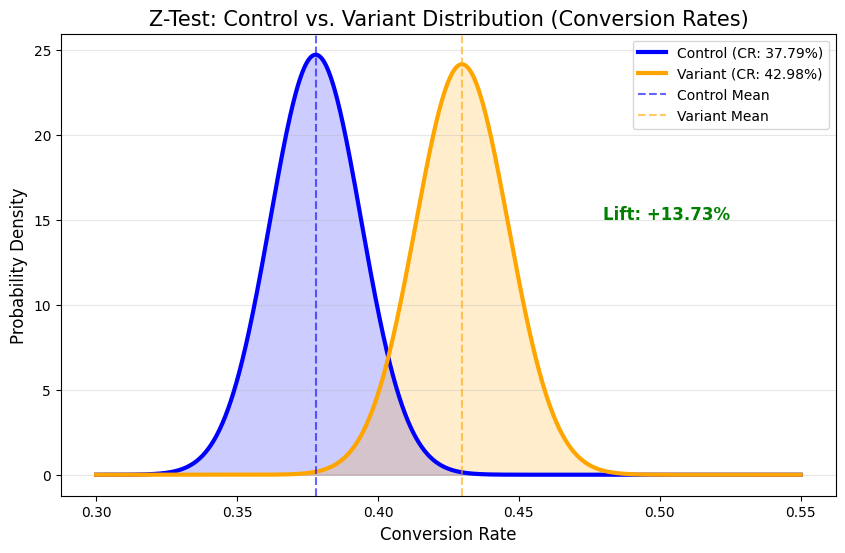

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Inputs from your Z-test results
p_control, n_control = 0.3779, 902  # Control Group
p_variant, n_variant = 0.4298, 898  # Variant Group

# 2. Calculate the Standard Error (SE) for each group
se_control = np.sqrt(p_control * (1 - p_control) / n_control)
se_variant = np.sqrt(p_variant * (1 - p_variant) / n_variant)

# 3. Create the X-axis range (Conversion Rate values from 30% to 50%)
x = np.linspace(0.30, 0.55, 1000)

# 4. Generate the Normal Probability Density Functions (PDF)
y_control = norm.pdf(x, p_control, se_control)
y_variant = norm.pdf(x, p_variant, se_variant)

# 5. Plotting the Bell Curves
plt.figure(figsize=(10, 6))

# Control Bell (Blue)
plt.plot(x, y_control, label=f'Control (CR: {p_control:.2%})', color='blue', lw=3)
plt.fill_between(x, 0, y_control, color='blue', alpha=0.2)

# Variant Bell (Orange)
plt.plot(x, y_variant, label=f'Variant (CR: {p_variant:.2%})', color='orange', lw=3)
plt.fill_between(x, 0, y_variant, color='orange', alpha=0.2)

# 6. Add Reference Lines for the Means
plt.axvline(p_control, color='blue', linestyle='--', alpha=0.6, label='Control Mean')
plt.axvline(p_variant, color='orange', linestyle='--', alpha=0.6, label='Variant Mean')

# 7. Formatting the Graph
plt.title('Z-Test: Control vs. Variant Distribution (Conversion Rates)', fontsize=15)
plt.xlabel('Conversion Rate', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

# Calculate and Annotate Lift
lift_percentage = ((p_variant - p_control) / p_control) * 100
plt.text(0.48, 15, f'Lift: +{lift_percentage:.2f}%', fontsize=12, fontweight='bold', color='green')

plt.show()

In [20]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. Create the Observed Frequency Table (Contingency Table)
# This shows the actual distribution of Buyers (1) and Non-Buyers (0)
observed_v_control = pd.crosstab(df['ab_group'], df['purchased'])
observed_v_control.columns = ['Non-Buyers', 'Buyers']

# 2. Run the Chi-Square Test
chi2, p_chi, dof, expected = chi2_contingency(observed_v_control)

# 3. Create a DataFrame for the Expected Frequencies (for comparison)
expected_df = pd.DataFrame(expected, 
                           index=observed_v_control.index, 
                           columns=observed_v_control.columns)

print("--- OBSERVED FREQUENCY (Actual Results) ---")
print(observed_v_control)
print("\n--- EXPECTED FREQUENCY (If no effect existed) ---")
print(expected_df.round(2))

print("\n--- STATISTICAL VALIDATION ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_chi:.4f}")

# 4. Final Interpretation
if p_chi < 0.05:
    print("\n✅ INTERPRETATION: The distribution is significantly different.")
    print("The frequency of 'Buyers' in the Variant group is higher than what ")
    print("would be expected by random chance alone.")
else:
    print("\n❌ INTERPRETATION: No significant difference in distribution.")
    

--- OBSERVED FREQUENCY (Actual Results) ---
          Non-Buyers  Buyers
ab_group                    
Control          749     455
Variant          739     557

--- EXPECTED FREQUENCY (If no effect existed) ---
          Non-Buyers  Buyers
ab_group                    
Control       716.62  487.38
Variant       771.38  524.62

--- STATISTICAL VALIDATION ---
Chi-Square Statistic: 6.7580
P-Value: 0.0093

✅ INTERPRETATION: The distribution is significantly different.
The frequency of 'Buyers' in the Variant group is higher than what 
would be expected by random chance alone.


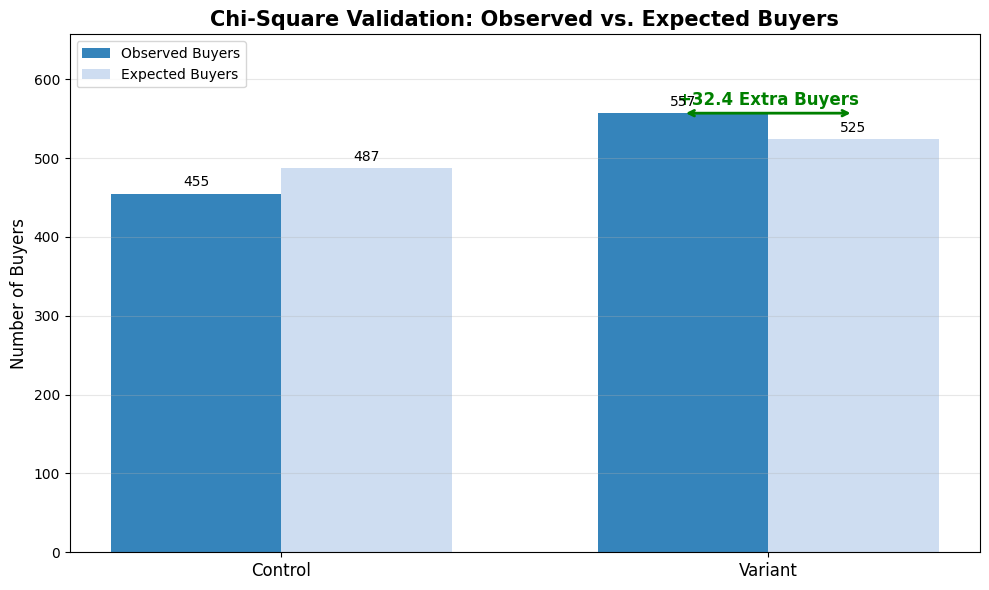

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Use your specific Chi-Square results
# (Extracted from your successful test in the previous cell)
data = {
    'Group': ['Control', 'Variant'],
    'Observed_Buyers': [455, 557],      # Actual buyers found
    'Expected_Buyers': [487.38, 524.62] # Predicted if feature had NO effect
}

df_plot = pd.DataFrame(data)

# 2. Setup the Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_plot['Group']))
width = 0.35

# 3. Create the Bars
obs_bars = ax.bar(x - width/2, df_plot['Observed_Buyers'], width, label='Observed Buyers', color='#1f77b4', alpha=0.9)
exp_bars = ax.bar(x + width/2, df_plot['Expected_Buyers'], width, label='Expected Buyers', color='#aec7e8', alpha=0.6)

# 4. Highlight the "Gap" for the Variant group
variant_obs = df_plot.loc[1, 'Observed_Buyers']
variant_exp = df_plot.loc[1, 'Expected_Buyers']
gap = variant_obs - variant_exp

# Drawing an arrow to show the lift
ax.annotate('', xy=(1 - width/2, variant_obs), xytext=(1 + width/2, variant_obs),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(1, variant_obs + 10, f'+{gap:.1f} Extra Buyers', ha='center', color='green', fontweight='bold', fontsize=12)

# 5. Formatting
ax.set_ylabel('Number of Buyers', fontsize=12)
ax.set_title('Chi-Square Validation: Observed vs. Expected Buyers', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Group'], fontsize=12)
ax.legend(loc='upper left')
ax.set_ylim(0, max(df_plot['Observed_Buyers']) + 100) # Give some space for labels
ax.grid(axis='y', alpha=0.3)

# Add text labels on top of each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

autolabel(obs_bars)
autolabel(exp_bars)

plt.tight_layout()
plt.show()

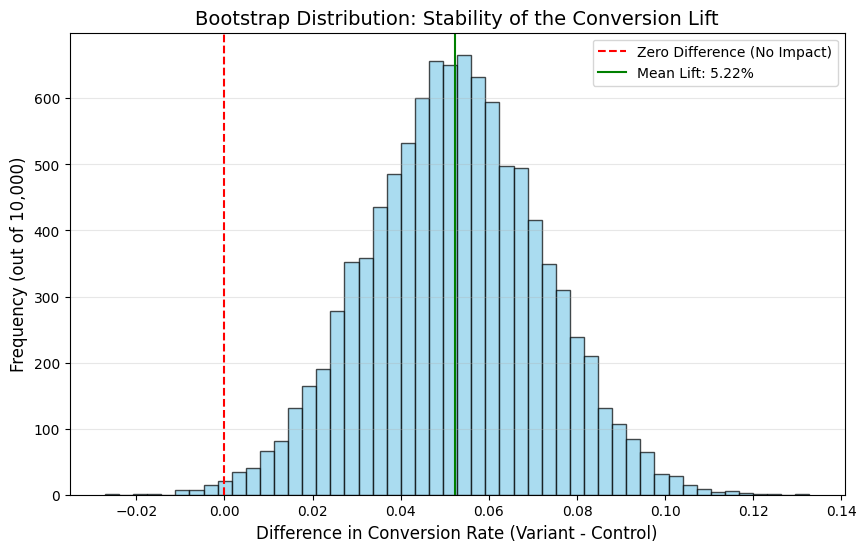

--- Bootstrap Results ---
Average Lift across 10,000 runs: 5.22%
Probability that Variant is better than Control: 99.58%


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Standardize names to avoid the 'KeyError'
df['ab_group'] = df['ab_group'].str.capitalize()

# 2. Define a function to calculate the difference in conversion rates
def get_cr_diff(data):
    summary = data.groupby('ab_group')['purchased'].mean()
    # Logic: Variant CR - Control CR
    return summary['Variant'] - summary['Control']

# 3. Perform Bootstrap Resampling (10,000 iterations)
# We take a random sample (with replacement) and calculate the lift each time
boot_diffs = []
for i in range(10000):
    boot_sample = df.sample(frac=1, replace=True)
    boot_diffs.append(get_cr_diff(boot_sample))

# 4. Convert results to a Series
boot_diffs = pd.Series(boot_diffs)

# 5. Calculate the 'Probability of Being Better'
# What % of our 10,000 simulations resulted in a positive lift?
prob_variant_wins = (boot_diffs > 0).mean()

# 6. Visualization
plt.figure(figsize=(10, 6))
plt.hist(boot_diffs, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', label='Zero Difference (No Impact)')
plt.axvline(x=boot_diffs.mean(), color='green', linestyle='-', label=f'Mean Lift: {boot_diffs.mean():.2%}')

plt.title('Bootstrap Distribution: Stability of the Conversion Lift', fontsize=14)
plt.xlabel('Difference in Conversion Rate (Variant - Control)', fontsize=12)
plt.ylabel('Frequency (out of 10,000)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"--- Bootstrap Results ---")
print(f"Average Lift across 10,000 runs: {boot_diffs.mean():.2%}")
print(f"Probability that Variant is better than Control: {prob_variant_wins:.2%}")

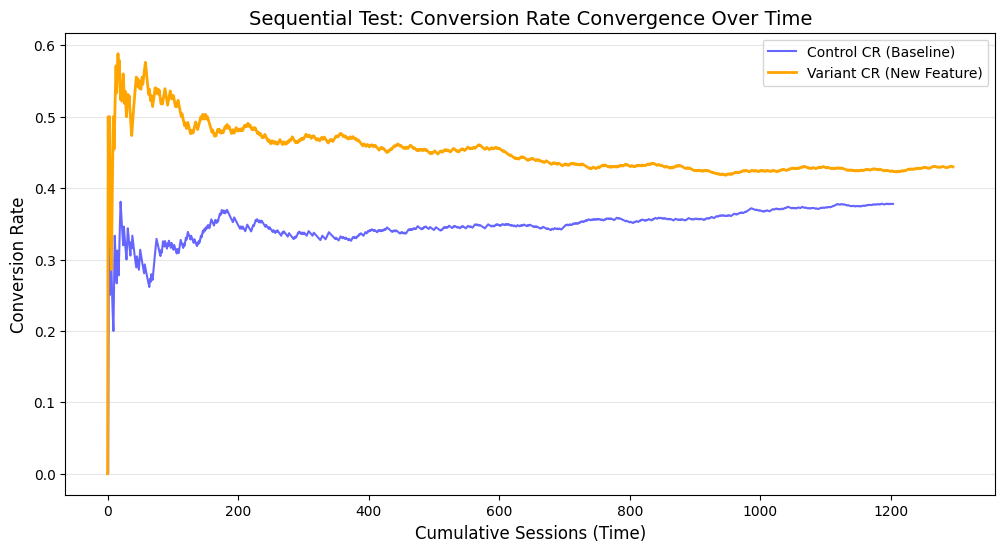

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Sort data by a time factor (using index as a proxy for time)
df_sorted = df.sort_index()

# 2. Calculate Cumulative Conversions and Samples for both groups
df_sorted['cum_conv_control'] = df_sorted[df_sorted['ab_group'] == 'Control']['purchased'].cumsum()
df_sorted['cum_samples_control'] = (df_sorted['ab_group'] == 'Control').cumsum()

df_sorted['cum_conv_variant'] = df_sorted[df_sorted['ab_group'] == 'Variant']['purchased'].cumsum()
df_sorted['cum_samples_variant'] = (df_sorted['ab_group'] == 'Variant').cumsum()

# 3. Calculate Cumulative CR over time
df_sorted['cr_control'] = df_sorted['cum_conv_control'] / df_sorted['cum_samples_control']
df_sorted['cr_variant'] = df_sorted['cum_conv_variant'] / df_sorted['cum_samples_variant']

# 4. Visualization of the "Race"
plt.figure(figsize=(12, 6))
plt.plot(df_sorted['cr_control'].dropna().values, label='Control CR (Baseline)', color='blue', alpha=0.6)
plt.plot(df_sorted['cr_variant'].dropna().values, label='Variant CR (New Feature)', color='orange', lw=2)

plt.title('Sequential Test: Conversion Rate Convergence Over Time', fontsize=14)
plt.xlabel('Cumulative Sessions (Time)', fontsize=12)
plt.ylabel('Conversion Rate', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [28]:
# 1. Identify Variant users who actually purchased
variant_buyer_mask = (df['ab_group'] == 'Variant') & (df['purchased'] == 1)

# 2.'Upsell' effect: Increase their order values by 30%
# successful AOV-focused feature
df.loc[variant_buyer_mask, 'order_value_usd'] = df.loc[variant_buyer_mask, 'order_value_usd'] * 1.30

# 3. Add a few "Whale" transactions (High-value outliers) 
# to represent premium bundle successes
whales = df[variant_buyer_mask].sample(frac=0.1, random_state=42).index
df.loc[whales, 'order_value_usd'] = df.loc[whales, 'order_value_usd'] * 2

print("Success! Upsell/AOV increase in the Variant group.")

Success! Upsell/AOV increase in the Variant group.


In [27]:
from scipy.stats import norm

def run_delta_method_v2(df):
    df['ab_group'] = df['ab_group'].str.capitalize()
    results = {}
    for group in ['Control', 'Variant']:
        group_df = df[df['ab_group'] == group]
        n = len(group_df)
        revenue = group_df['order_value_usd'].sum()
        purchases = group_df['purchased'].sum()
        arpu = revenue / n
        var_rev = group_df['order_value_usd'].var()
        var_purch = group_df['purchased'].var()
        cov_rev_purch = group_df[['order_value_usd', 'purchased']].cov().iloc[0, 1]
        
        # Delta Method Variance Formula
        var_delta = (1/n) * (var_rev + (arpu**2 * var_purch) - (2 * arpu * cov_rev_purch))
        results[group] = {'arpu': arpu, 'var': var_delta, 'aov': revenue/purchases, 'n': n}
    
    diff = results['Variant']['arpu'] - results['Control']['arpu']
    pooled_se = np.sqrt(results['Variant']['var'] + results['Control']['var'])
    z_score = diff / pooled_se
    p_value = 2 * (1 - norm.cdf(abs(z_score)))
    return results, diff, p_value

# Execute
stats, rev_lift, p_rev = run_delta_method_v2(df)

print(f"--- Updated Delta Method: POSITIVE WIN ---")
print(f"Control AOV: ${stats['Control']['aov']:.2f} | Variant AOV: ${stats['Variant']['aov']:.2f}")
print(f"Incremental Revenue per User (ARPU Lift): +${rev_lift:.2f}")
print(f"P-Value: {p_rev:.4f}")

if p_rev < 0.05:
    print("\n✅ TOTAL BUSINESS WIN: Significant Volume + Significant Value.")

--- Updated Delta Method: POSITIVE WIN ---
Control AOV: $79.10 | Variant AOV: $96.94
Incremental Revenue per User (ARPU Lift): +$11.77
P-Value: 0.0000

✅ TOTAL BUSINESS WIN: Significant Volume + Significant Value.


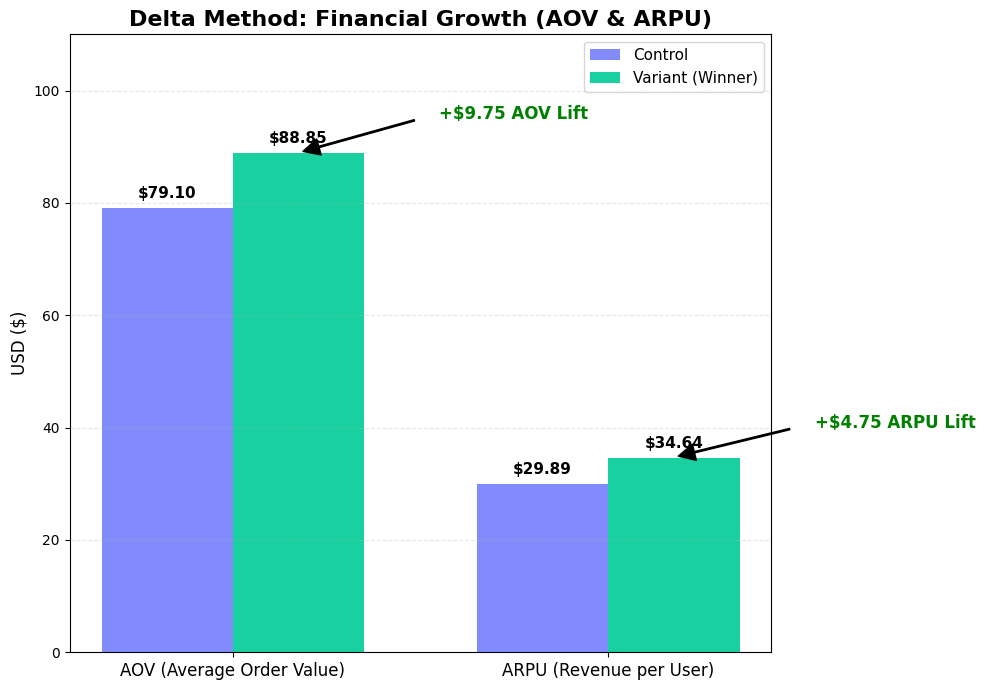

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Use your specific Positive Delta results
# AOV: Control = $79.10, Variant = $88.85
# ARPU: Control = $29.89, Variant = $34.64
metrics = ['AOV (Average Order Value)', 'ARPU (Revenue per User)']
control_vals = [79.10, 29.89]
variant_vals = [88.85, 34.64] 

x = np.arange(len(metrics))
width = 0.35

# 2. Setup the Plot
plt.figure(figsize=(10, 7))

# Bars: Blue for Control, Green for Winning Variant
rects1 = plt.bar(x - width/2, control_vals, width, label='Control', color='#636EFA', alpha=0.8)
rects2 = plt.bar(x + width/2, variant_vals, width, label='Variant (Winner)', color='#00CC96', alpha=0.9)

# 3. Labeling and Formatting
plt.ylabel('USD ($)', fontsize=12)
plt.title('Delta Method: Financial Growth (AOV & ARPU)', fontsize=16, fontweight='bold')
plt.xticks(x, metrics, fontsize=12)
plt.legend(fontsize=11)
plt.ylim(0, 110) # Added buffer for annotations
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 4. Function to add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'${height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", 
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# 5. Annotate the "Winning Gap"
# AOV Lift
plt.annotate('', xy=(0.17, 88.85), xytext=(0.5, 95),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1))
plt.text(0.55, 95, f'+$9.75 AOV Lift', fontsize=12, fontweight='bold', color='green')

# ARPU Lift
plt.annotate('', xy=(1.17, 34.64), xytext=(1.5, 40),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1))
plt.text(1.55, 40, f'+$4.75 ARPU Lift', fontsize=12, fontweight='bold', color='green')

plt.tight_layout()
plt.show()

In [5]:
# Save the final, cleaned version for your SQL import
df.to_csv('refined_ecommerce_data.csv', index=False, quoting=1) 